In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shap

from scipy import sparse
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pd.set_option("display.max_columns", None)

In [2]:
os.makedirs("../results/xai", exist_ok=True)

In [3]:
best_model = joblib.load("../results/models/best_model.pkl")
best_model_name = joblib.load("../results/models/best_model_name.pkl")

X_train = joblib.load("../results/models/X_train.pkl")
X_test = joblib.load("../results/models/X_test.pkl")
y_train = joblib.load("../results/models/y_train.pkl")
y_test = joblib.load("../results/models/y_test.pkl")

numeric_features = joblib.load("../results/models/numeric_features.pkl")
categorical_features = joblib.load("../results/models/categorical_features.pkl")

print("Modelo cargado:", best_model_name)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Modelo cargado: Gradient Boosting
X_train: (3539, 28)
X_test: (885, 28)
y_train: (3539,)
y_test: (885,)


In [4]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

print("Preprocesador:", type(preprocessor))
print("Modelo interno:", type(model))

Preprocesador: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Modelo interno: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [5]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Dropout", "Dropout"]
))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

  No Dropout       0.87      0.93      0.90       601
     Dropout       0.83      0.71      0.76       284

    accuracy                           0.86       885
   macro avg       0.85      0.82      0.83       885
weighted avg       0.86      0.86      0.86       885

ROC-AUC: 0.9077007803894916
Matriz de confusión:
[[560  41]
 [ 83 201]]


In [6]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if sparse.issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()

if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

feature_names_clean = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names_clean,
    index=X_train.index
)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names_clean,
    index=X_test.index
)

print("X_train_shap:", X_train_shap.shape)
print("X_test_shap:", X_test_shap.shape)

X_test_shap.head()

X_train_shap: (3539, 242)
X_test_shap: (885, 242)


,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,Marital status_1,Marital status_2,Marital status_3,Marital status_4,Marital status_5,Marital status_6,Application mode_1,Application mode_2,Application mode_3,Application mode_4,Application mode_5,Application mode_6,Application mode_7,Application mode_8,Application mode_9,Application mode_10,Application mode_11,Application mode_12,Application mode_13,Application mode_14,Application mode_15,Application mode_16,Application mode_17,Application mode_18,Application order_0,Application order_1,Application order_2,Application order_3,Application order_4,Application order_5,Application order_6,Application order_9,Course_1,Course_2,Course_3,Course_4,Course_5,Course_6,Course_7,Course_8,Course_9,Course_10,Course_11,Course_12,Course_13,Course_14,Course_15,Course_16,Course_17,Daytime/evening attendance_0,Daytime/evening attendance_1,Previous qualification_1,Previous qualification_2,Previous qualification_3,Previous qualification_4,Previous qualification_5,Previous qualification_6,Previous qualification_7,Previous qualification_8,Previous qualification_9,Previous qualification_11,Previous qualification_12,Previous qualification_13,Previous qualification_14,Previous qualification_15,Previous qualification_16,Previous qualification_17,Nacionality_1,Nacionality_2,Nacionality_3,Nacionality_4,Nacionality_5,Nacionality_6,Nacionality_7,Nacionality_8,Nacionality_9,Nacionality_10,Nacionality_11,Nacionality_12,Nacionality_14,Nacionality_15,Nacionality_16,Nacionality_17,Nacionality_18,Nacionality_19,Nacionality_21,Mother's qualification_1,Mother's qualification_2,Mother's qualification_3,Mother's qualification_4,Mother's qualification_5,Mother's qualification_6,Mother's qualification_7,Mother's qualification_8,Mother's qualification_9,Mother's qualification_10,Mother's qualification_11,Mother's qualification_13,Mother's qualification_14,Mother's qualification_15,Mother's qualification_17,Mother's qualification_18,Mother's qualification_19,Mother's qualification_20,Mother's qualification_21,Mother's qualification_22,Mother's qualification_23,Mother's qualification_24,Mother's qualification_25,Mother's qualification_26,Mother's qualification_27,Mother's qualification_28,Mother's qualification_29,Father's qualification_1,Father's qualification_2,Father's qualification_3,Father's qualification_4,Father's qualification_5,Father's qualification_6,Father's qualification_7,Father's qualification_8,Father's qualification_9,Father's qualification_10,Father's qualification_12,Father's qualification_14,Father's qualification_15,Father's qualification_16,Father's qualification_17,Father's qualification_18,Father's qualification_19,Father's qualification_20,Father's qualification_21,Father's qualification_22,Father's qualification_23,Father's qualification_24,Father's qualification_25,Father's qualification_26,Father's qualification_27,Father's qualification_28,Father's qualification_29,Father's qualification_30,Father's qualification_31,Father's qualification_33,Father's qualification_34,Mother's occupation_1,Mother's occupation_2,Mother's occupation_3,Mother's occupation_4,Mother's occupation_5,Mother's occupation_6,Mother's occupation_7,Mother's occupation_8,Mother's occupation_9,Mother's occupation_10,Mother's occupation_11,Mother's occupation_12,Mother's occupation_13,Mother's occupation_14,Mother's occupation_15,Mother's occupation_16,Mother's occupation_17,Mother's occupation_18,Mother's occupation_19,Mother's occupation_20,Mother's occupation_21,Mother's occupation_22,Mother's occupation_23,Mother's occupation_24,Mother's occupation_25,Mother's occupation_26,Mother's occupation_28,Mother's occupation_29,Mother's occupation_30,Mother's occupation_31,Mother's occupation_32,Father's

In [7]:
sample_size = min(500, X_test_shap.shape[0])

X_explain = X_test_shap.sample(
    n=sample_size,
    random_state=42
)

print("Muestra usada para SHAP:", X_explain.shape)

Muestra usada para SHAP: (500, 242)


In [9]:
background_size = min(200, X_train_shap.shape[0])

X_background = X_train_shap.sample(
    n=background_size,
    random_state=42
)

explainer = shap.TreeExplainer(
    model,
    data=X_background,
    feature_names=X_train_shap.columns
)

shap_values_array = explainer.shap_values(
    X_explain,
    check_additivity=False
)

shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=np.repeat(explainer.expected_value, X_explain.shape[0]),
    data=X_explain.values,
    feature_names=X_explain.columns
)

shap_values

.values =
array([[ 0.48555121, -0.00107765,  0.14767792, ...,  0.04055714,
         0.        ,  0.        ],
       [-0.21975353, -0.05856426, -0.31460651, ..., -0.10419798,
         0.        ,  0.        ],
       [ 0.40897214, -0.06512996,  0.10306249, ...,  0.05519672,
         0.        ,  0.        ],
       ...,
       [-0.25913199, -0.05673145, -0.4566371 , ..., -0.1197656 ,
         0.        ,  0.        ],
       [ 0.3132307 , -0.0690383 ,  0.13462671, ..., -0.20010279,
         0.        ,  0.        ],
       [-0.12345355, -0.06848139,  0.10175995, ...,  0.02576074,
         0.        ,  0.        ]])

.base_values =
array([-0.75730329, -0.75730329, -0.75730329, -0.75730329, -0.75730329,
       -0.75730329, -0.75730329, -0.75730329, -0.75730329, -0.75730329,
       -0.75730329, -0.75730329, -0.75730329, -0.75730329, -0.75730329,
       -0.75730329, -0.75730329, -0.75730329, -0.75730329, -0.75730329,
       -0.75730329, -0.75730329, -0.75730329, -0.75730329, -0.75730329,
 

In [10]:
shap_values_dropout = shap_values

print("Dimensión valores SHAP:", shap_values_dropout.values.shape)

Dimensión valores SHAP: (500, 242)


In [11]:
mean_abs_shap = np.abs(shap_values_dropout.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
4,Curricular units 1st sem (approved),1.152171
0,Age at enrollment,0.337668
235,Tuition fees up to date_1,0.274604
2,Curricular units 1st sem (enrolled),0.272966
234,Tuition fees up to date_0,0.226844
5,Curricular units 1st sem (grade),0.225249
7,Unemployment rate,0.160011
238,Scholarship holder_0,0.118708
1,Curricular units 1st sem (credited),0.107197
3,Curricular units 1st sem (evaluations),0.106595


In [13]:
shap_importance.to_csv(
    "../results/tables/shap_feature_importance.csv",
    index=False
)

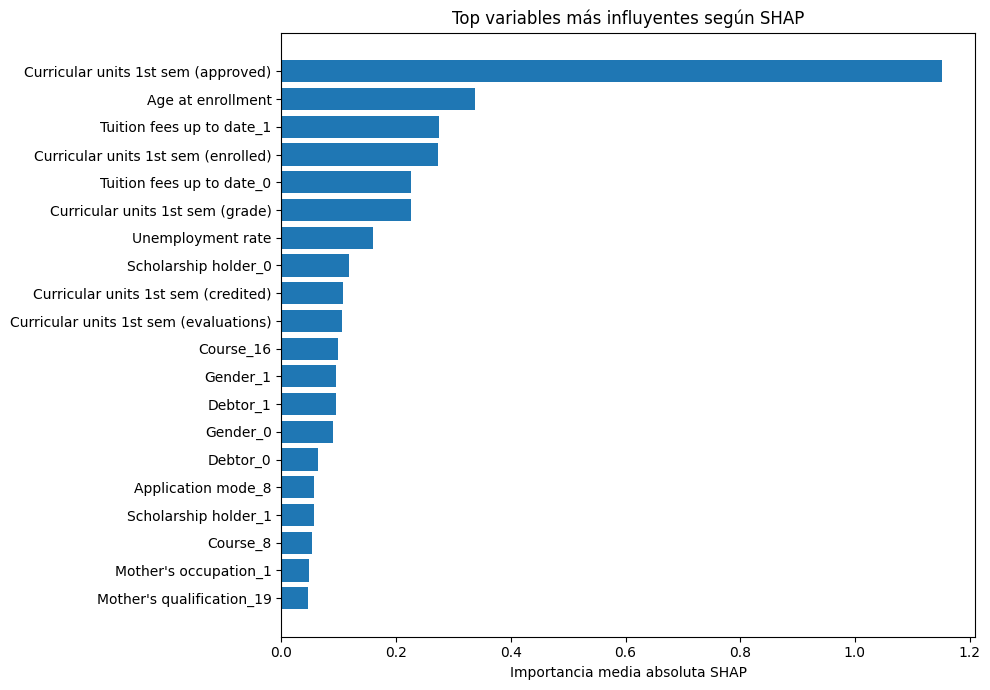

In [14]:
top_n = 20

plt.figure(figsize=(10, 7))
plt.barh(
    shap_importance.head(top_n)["feature"][::-1],
    shap_importance.head(top_n)["mean_abs_shap"][::-1]
)
plt.xlabel("Importancia media absoluta SHAP")
plt.title("Top variables más influyentes según SHAP")
plt.tight_layout()
plt.savefig("../results/figures/shap_global_importance_bar.png", dpi=300)
plt.show()

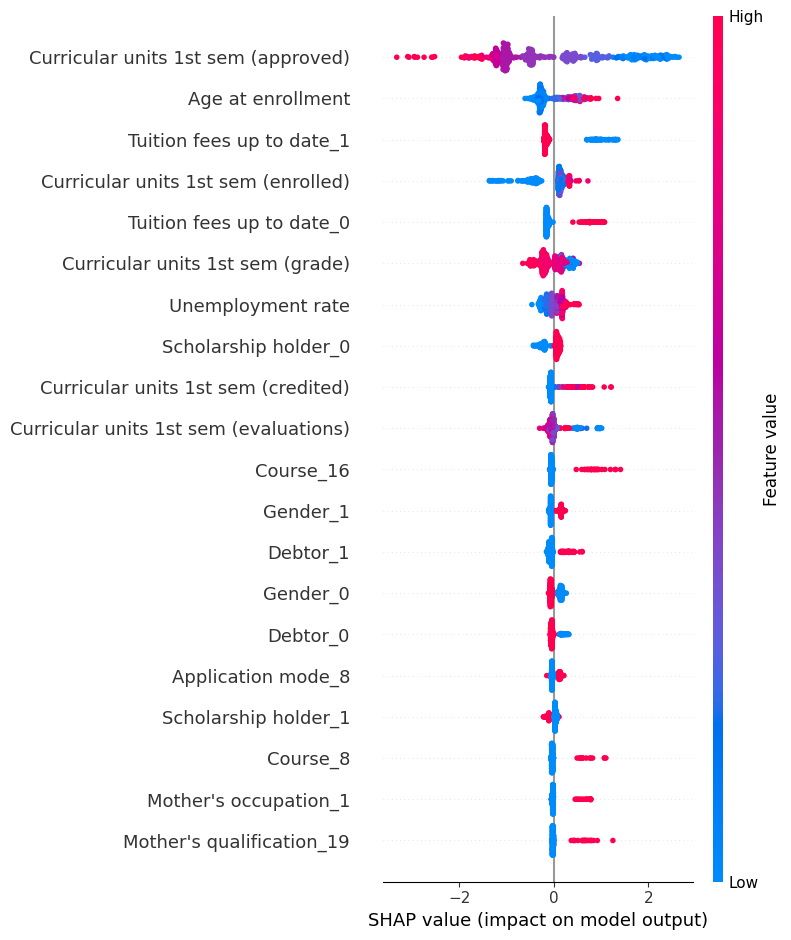

In [15]:
shap.summary_plot(
    shap_values_dropout.values,
    X_explain,
    feature_names=X_explain.columns,
    show=False
)

plt.tight_layout()
plt.savefig("../results/figures/shap_summary_plot.png", dpi=300)
plt.show()

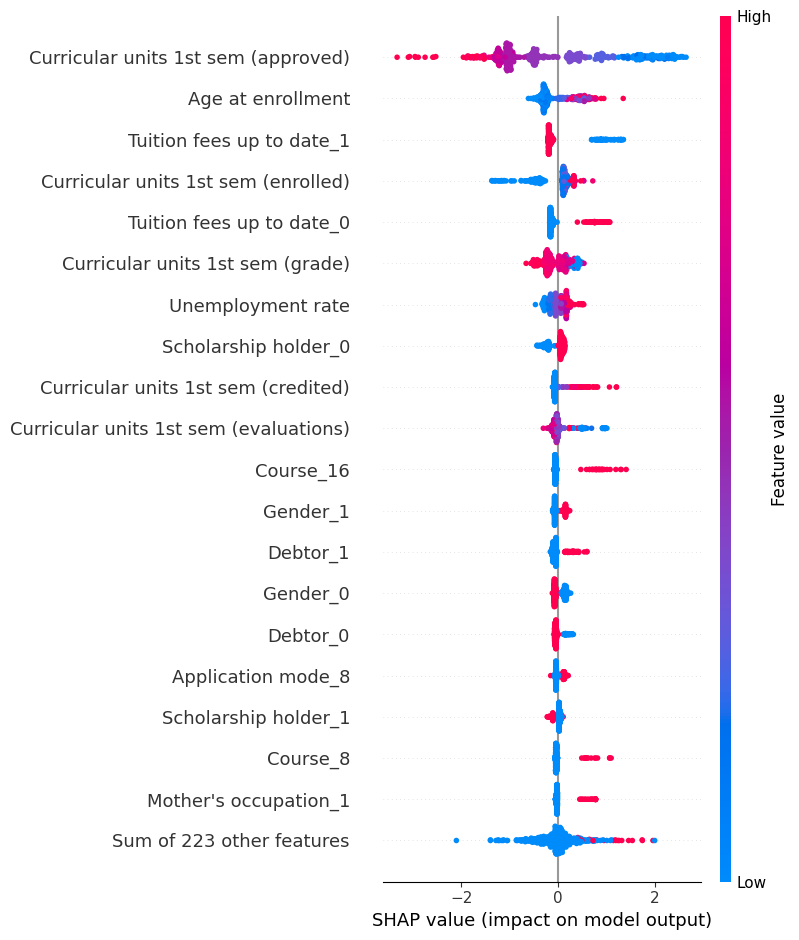

In [17]:
shap.plots.beeswarm(
    shap_values_dropout,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig("../results/figures/shap_beeswarm.png", dpi=300)
plt.show()

In [18]:
predictions_df = X_test.copy()
predictions_df["y_real"] = y_test.values
predictions_df["y_pred"] = y_pred
predictions_df["y_proba_dropout"] = y_proba

high_risk_idx = predictions_df["y_proba_dropout"].idxmax()
low_risk_idx = predictions_df["y_proba_dropout"].idxmin()
borderline_idx = (predictions_df["y_proba_dropout"] - 0.5).abs().idxmin()

selected_cases = {
    "alto_riesgo": high_risk_idx,
    "bajo_riesgo": low_risk_idx,
    "caso_dudoso": borderline_idx
}

selected_cases

{'alto_riesgo': 2004, 'bajo_riesgo': 1977, 'caso_dudoso': 3022}

In [19]:
case_summary = predictions_df.loc[
    list(selected_cases.values()),
    ["y_real", "y_pred", "y_proba_dropout"]
]

case_summary

,y_real,y_pred,y_proba_dropout
2004,1,1,0.995337
1977,0,0,0.010442
3022,1,1,0.500413


In [20]:
def explain_case(case_name, original_index):
    case_transformed = X_test_shap.loc[[original_index]]
    
    shap_values_case_array = explainer.shap_values(
        case_transformed,
        check_additivity=False
    )
    
    case_explanation = shap.Explanation(
        values=shap_values_case_array[0],
        base_values=explainer.expected_value,
        data=case_transformed.iloc[0].values,
        feature_names=case_transformed.columns
    )
    
    shap.plots.waterfall(
        case_explanation,
        max_display=15,
        show=False
    )
    
    plt.title(f"Explicación local SHAP - {case_name}")
    plt.tight_layout()
    plt.savefig(f"../results/figures/shap_waterfall_{case_name}.png", dpi=300)
    plt.show()
    
    local_df = pd.DataFrame({
        "feature": case_explanation.feature_names,
        "feature_value": case_explanation.data,
        "shap_value": case_explanation.values,
        "abs_shap_value": np.abs(case_explanation.values)
    }).sort_values(by="abs_shap_value", ascending=False)
    
    local_df.to_csv(
        f"../results/tables/shap_local_{case_name}.csv",
        index=False
    )
    
    return local_df.head(15)

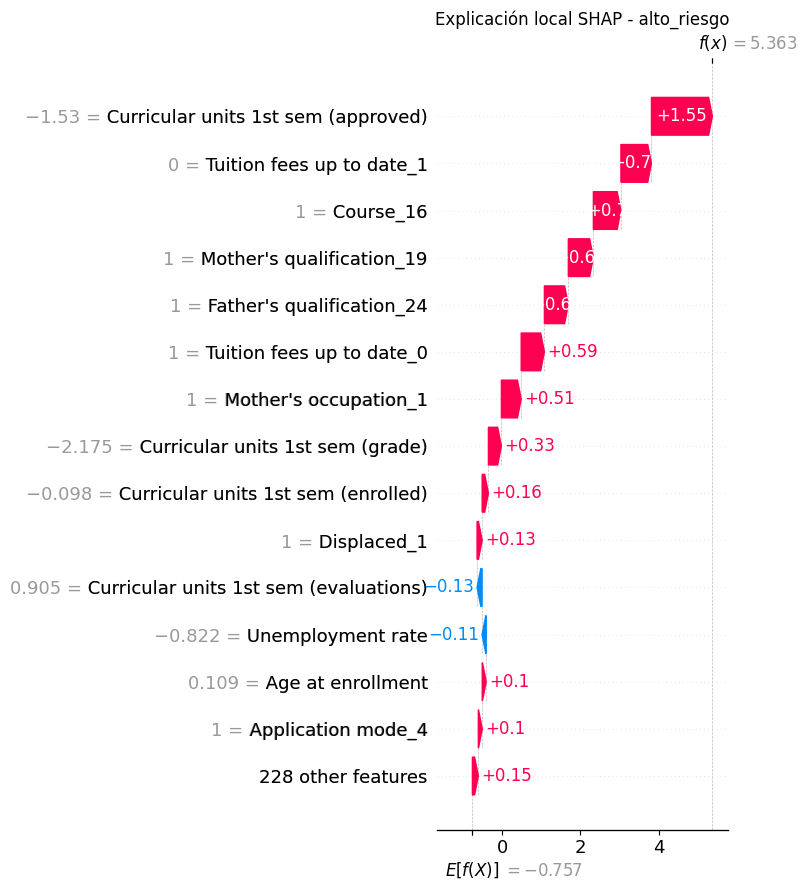

,feature,feature_value,shap_value,abs_shap_value
4,Curricular units 1st sem (approved),-1.529833,1.553256,1.553256
235,Tuition fees up to date_1,0.000000,0.779122,0.779122
57,Course_16,1.000000,0.702664,0.702664
112,Mother's qualification_19,1.000000,0.638583,0.638583
144,Father's qualification_24,1.000000,0.610513,0.610513
234,Tuition fees up to date_0,1.000000,0.591913,0.591913
154,Mother's occupation_1,1.000000,0.505135,0.505135
5,Curricular units 1st sem (grade),-2.174871,0.330732,0.330732
2,Curricular units 1st sem (enrolled),-0.097893,0.158933,0.158933
229,Displaced_1,1.000000,0.130536,0.130536


In [21]:
explain_case("alto_riesgo", selected_cases["alto_riesgo"])

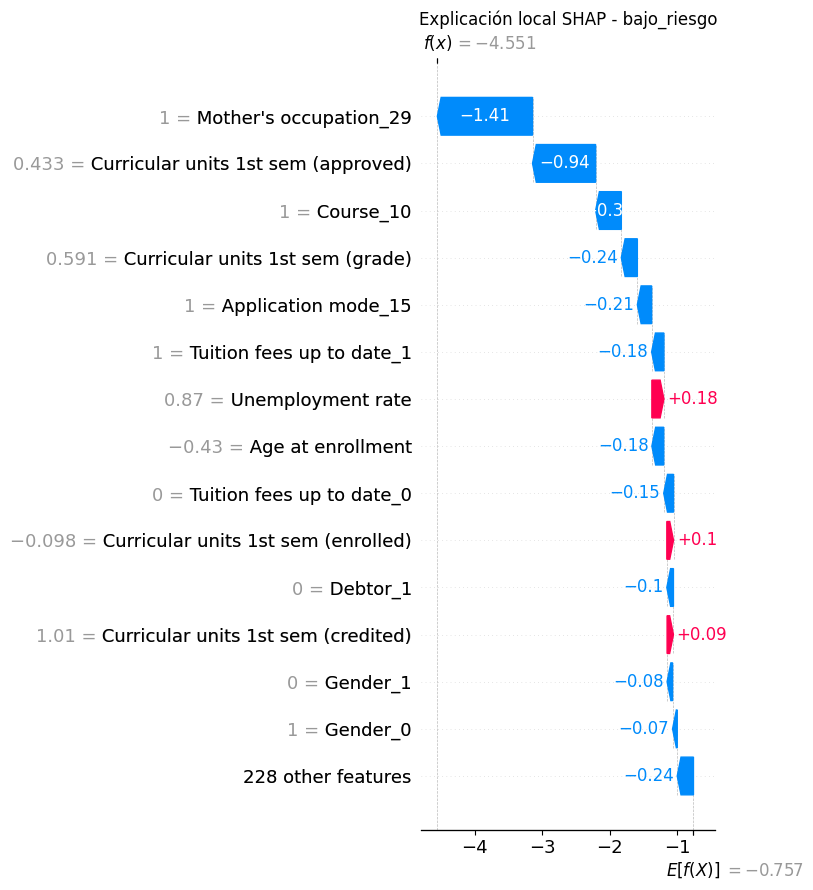

,feature,feature_value,shap_value,abs_shap_value
181,Mother's occupation_29,1.000000,-1.409585,1.409585
4,Curricular units 1st sem (approved),0.432619,-0.935064,0.935064
51,Course_10,1.000000,-0.380957,0.380957
5,Curricular units 1st sem (grade),0.590779,-0.237224,0.237224
30,Application mode_15,1.000000,-0.211817,0.211817
235,Tuition fees up to date_1,1.000000,-0.181649,0.181649
7,Unemployment rate,0.869984,0.178245,0.178245
0,Age at enrollment,-0.430207,-0.175611,0.175611
234,Tuition fees up to date_0,0.000000,-0.145099,0.145099
2,Curricular units 1st sem (enrolled),-0.097893,0.099181,0.099181


In [22]:
explain_case("bajo_riesgo", selected_cases["bajo_riesgo"])

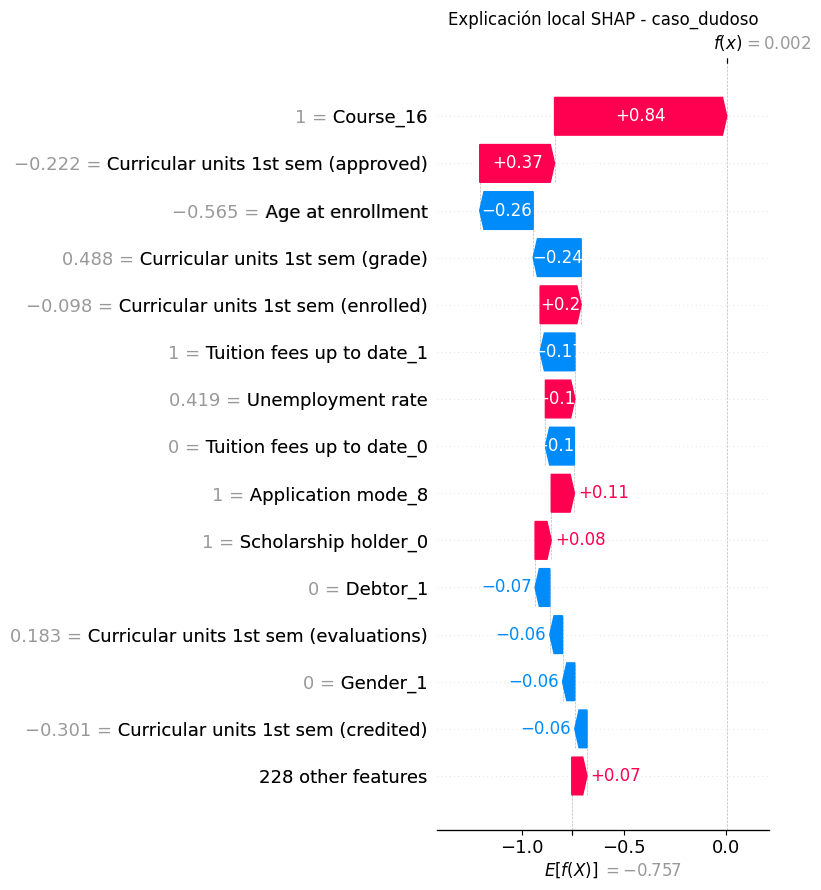

,feature,feature_value,shap_value,abs_shap_value
57,Course_16,1.000000,0.843168,0.843168
4,Curricular units 1st sem (approved),-0.221531,0.366516,0.366516
0,Age at enrollment,-0.564942,-0.261770,0.261770
5,Curricular units 1st sem (grade),0.488348,-0.235013,0.235013
2,Curricular units 1st sem (enrolled),-0.097893,0.200989,0.200989
235,Tuition fees up to date_1,1.000000,-0.170526,0.170526
7,Unemployment rate,0.418796,0.144694,0.144694
234,Tuition fees up to date_0,0.000000,-0.142072,0.142072
23,Application mode_8,1.000000,0.113478,0.113478
238,Scholarship holder_0,1.000000,0.079031,0.079031


In [23]:
explain_case("caso_dudoso", selected_cases["caso_dudoso"])

In [24]:
def get_original_feature_name(feature_name):
    for col in categorical_features:
        if feature_name.startswith(col + "_"):
            return col
    return feature_name

shap_importance_grouped = shap_importance.copy()
shap_importance_grouped["original_feature"] = shap_importance_grouped["feature"].apply(
    get_original_feature_name
)

shap_importance_grouped = (
    shap_importance_grouped
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values(by="mean_abs_shap", ascending=False)
)

shap_importance_grouped.head(20)

,original_feature,mean_abs_shap
4,Curricular units 1st sem (approved),1.152171
26,Tuition fees up to date,0.501448
3,Course,0.347632
0,Age at enrollment,0.337668
6,Curricular units 1st sem (enrolled),0.272966
8,Curricular units 1st sem (grade),0.225249
17,Gender,0.185162
25,Scholarship holder,0.174914
27,Unemployment rate,0.160011
11,Debtor,0.158820


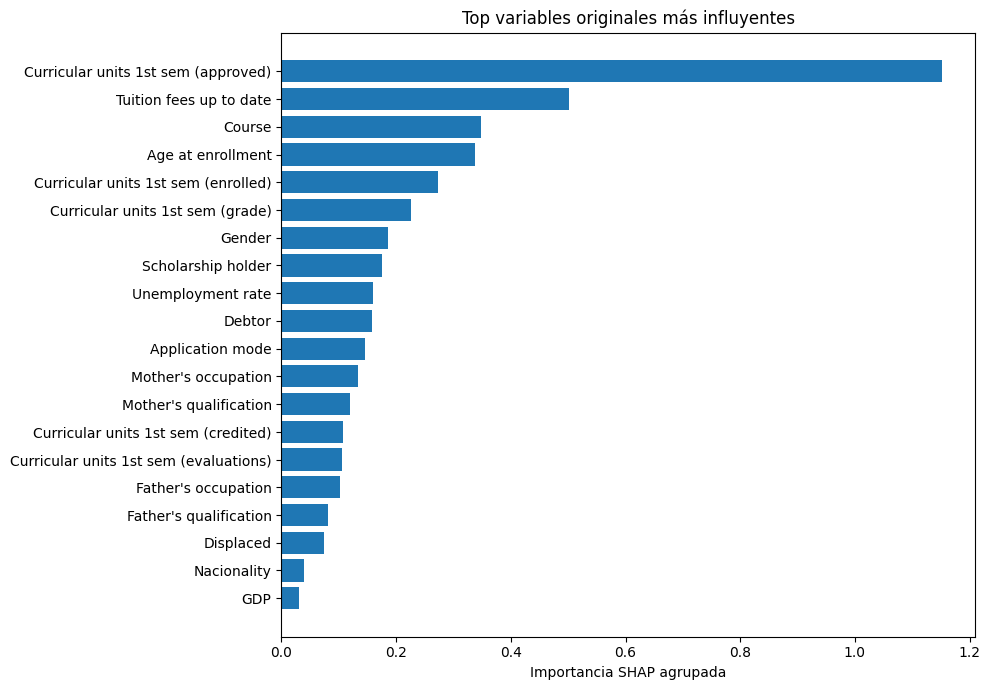

In [25]:
shap_importance_grouped.to_csv(
    "../results/tables/shap_feature_importance_grouped.csv",
    index=False
)

plt.figure(figsize=(10, 7))
plt.barh(
    shap_importance_grouped.head(20)["original_feature"][::-1],
    shap_importance_grouped.head(20)["mean_abs_shap"][::-1]
)
plt.xlabel("Importancia SHAP agrupada")
plt.title("Top variables originales más influyentes")
plt.tight_layout()
plt.savefig("../results/figures/shap_grouped_importance.png", dpi=300)
plt.show()

In [26]:
presentation_summary = shap_importance_grouped.head(10).copy()
presentation_summary.columns = ["Variable", "Importancia_SHAP"]

presentation_summary.to_csv(
    "../results/tables/shap_top10_for_presentation.csv",
    index=False
)

presentation_summary

,Variable,Importancia_SHAP
4,Curricular units 1st sem (approved),1.152171
26,Tuition fees up to date,0.501448
3,Course,0.347632
0,Age at enrollment,0.337668
6,Curricular units 1st sem (enrolled),0.272966
8,Curricular units 1st sem (grade),0.225249
17,Gender,0.185162
25,Scholarship holder,0.174914
27,Unemployment rate,0.160011
11,Debtor,0.158820


In [27]:
joblib.dump(shap_importance, "../results/xai/shap_importance.pkl")
joblib.dump(shap_importance_grouped, "../results/xai/shap_importance_grouped.pkl")
joblib.dump(selected_cases, "../results/xai/selected_cases.pkl")

['../results/xai/selected_cases.pkl']

In [28]:
paths_to_check = [
    "../results/tables/shap_feature_importance.csv",
    "../results/tables/shap_feature_importance_grouped.csv",
    "../results/tables/shap_top10_for_presentation.csv",
    "../results/tables/shap_local_alto_riesgo.csv",
    "../results/tables/shap_local_bajo_riesgo.csv",
    "../results/tables/shap_local_caso_dudoso.csv",
    "../results/figures/shap_global_importance_bar.png",
    "../results/figures/shap_summary_plot.png",
    "../results/figures/shap_beeswarm.png",
    "../results/figures/shap_waterfall_alto_riesgo.png",
    "../results/figures/shap_waterfall_bajo_riesgo.png",
    "../results/figures/shap_waterfall_caso_dudoso.png",
    "../results/figures/shap_grouped_importance.png",
    "../results/xai/shap_importance.pkl",
    "../results/xai/shap_importance_grouped.pkl",
    "../results/xai/selected_cases.pkl",
]

for path in paths_to_check:
    print(path, "OK" if os.path.exists(path) else "FALTA")

../results/tables/shap_feature_importance.csv OK
../results/tables/shap_feature_importance_grouped.csv OK
../results/tables/shap_top10_for_presentation.csv OK
../results/tables/shap_local_alto_riesgo.csv OK
../results/tables/shap_local_bajo_riesgo.csv OK
../results/tables/shap_local_caso_dudoso.csv OK
../results/figures/shap_global_importance_bar.png OK
../results/figures/shap_summary_plot.png OK
../results/figures/shap_beeswarm.png OK
../results/figures/shap_waterfall_alto_riesgo.png OK
../results/figures/shap_waterfall_bajo_riesgo.png OK
../results/figures/shap_waterfall_caso_dudoso.png OK
../results/figures/shap_grouped_importance.png OK
../results/xai/shap_importance.pkl OK
../results/xai/shap_importance_grouped.pkl OK
../results/xai/selected_cases.pkl OK
